# **Bài Toán 1 - Nhiệm vụ 3: Xây dựng rừng cây (random forest)**

## **1. Tải một số package và package graphviz**

In [1]:
import numpy as np #numerical computation
import pandas as pd #data wrangling
import matplotlib.pyplot as plt #plotting package
#Next line helps with rendering plots
%matplotlib inline
import matplotlib as mpl #add'l plotting functionality
mpl.rcParams['figure.dpi'] = 400 #high res figures
import graphviz #to visualize decision trees

## **2. Nạp dữ liệu vào bộ nhớ, phân tích và loại bỏ những features không liên quan**

In [2]:
df = pd.read_csv('dataset/default_of_credit_card_clients.csv') #Load the cleaned data
features_response = df.columns.tolist() #Get a list of column names
#Make a list of columns to remove that aren't features or the response variable
items_to_remove = ['ID', 'SEX', 'PAY_2', 'PAY_3',\
'PAY_4', 'PAY_5', 'PAY_6',\
'EDUCATION_CAT', 'graduate school',\
'high school', 'none',\
'others', 'university']
features_response = [item for item in features_response if item not
in items_to_remove]
features_response

['LIMIT_BAL',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

## **3. Chuẩn bị dữ liệu cho tập train và tập test**

In [3]:
from sklearn.model_selection import train_test_split
from sklearn import tree
#Split the data into training and testing sets using the same random seed
X_train, X_test, y_train, y_test = \
train_test_split(df[features_response[:-1]].values,
df['default payment next month'].values,
test_size=0.2, random_state=24)

## **4. Tạo rừng cây với lớp RandomForestClassifier trong Scikit-Learn**

In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier\
(n_estimators=10, criterion='gini', max_depth=3,
min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0,
max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0,
bootstrap=True, oob_score=False, n_jobs=None,
random_state=4, verbose=0, warm_start=False, class_weight=None)

## **5. Tìm tham số tối ưu cho mô hình rừng cây và thực hiện train với tham số tối ưu đó**

In [6]:
#a parameter grid for this exercise in order to search the numbers of trees, ranging from 10 to 100 by 10s
rf_params_ex = {'n_estimators':list(range(10,110,10))}
cv_rf_ex = GridSearchCV(rf, param_grid=rf_params_ex,
scoring='roc_auc', n_jobs=None,
refit=True, cv=4, verbose=1,
error_score=np.nan,
return_train_score=True)

cv_rf_ex.fit(X_train, y_train)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


GridSearchCV(cv=4,
             estimator=RandomForestClassifier(max_depth=3, n_estimators=10,
                                              random_state=4),
             param_grid={'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90,
                                          100]},
             return_train_score=True, scoring='roc_auc', verbose=1)

## **6. Vẽ biểu đồ đánh giá mô hình rừng cây với các tham số số cây có trong rừng khác nhau**

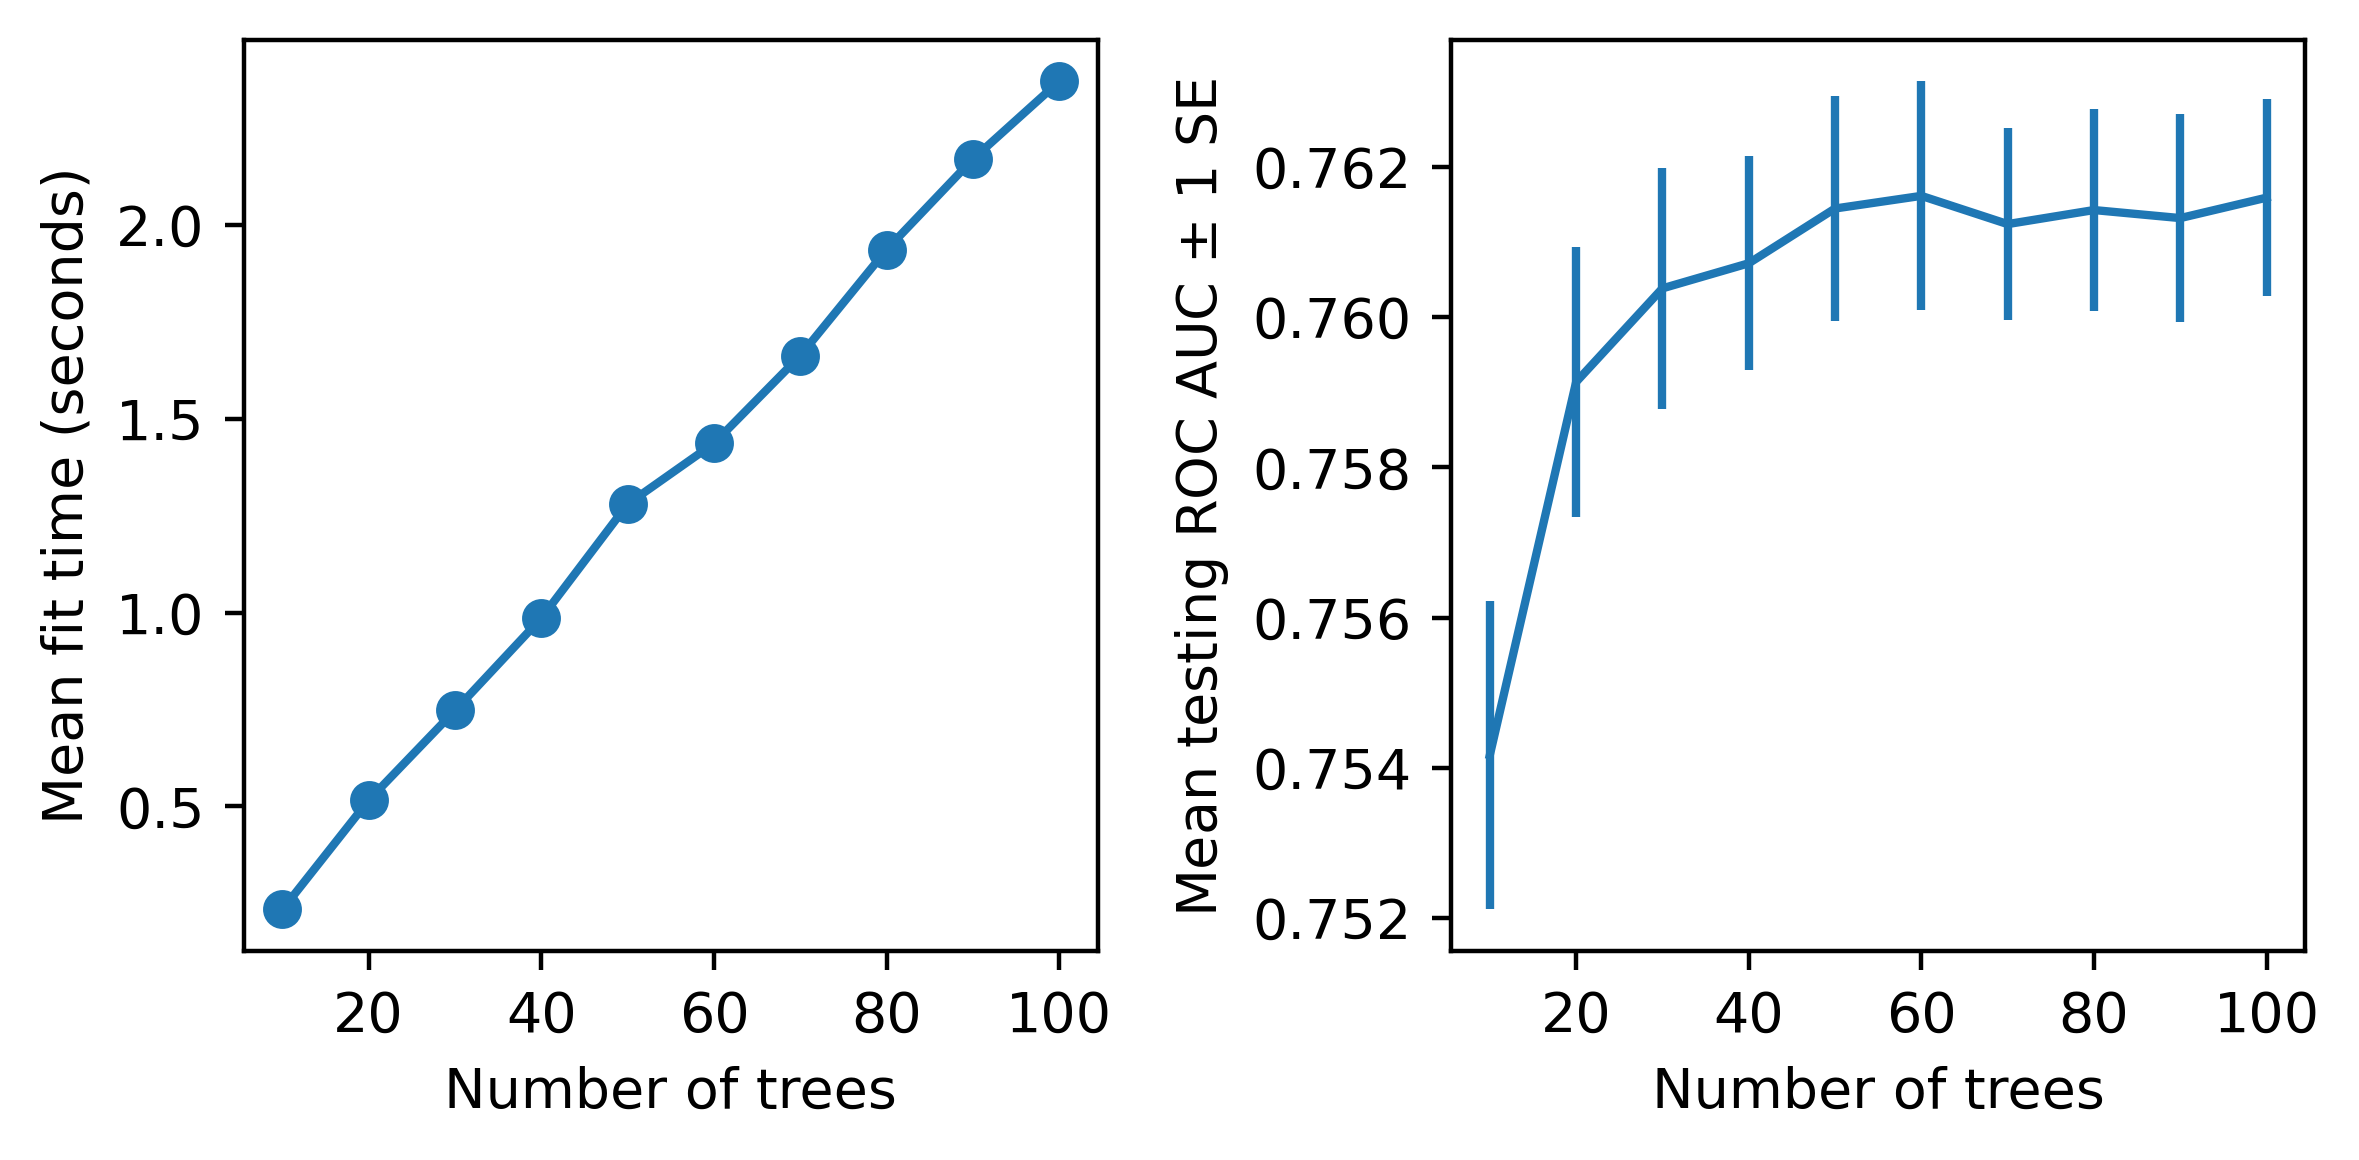

In [7]:
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
axs[0].plot(cv_rf_ex_results_df['param_n_estimators'],
cv_rf_ex_results_df['mean_fit_time'],
'-o')
axs[0].set_xlabel('Number of trees')
axs[0].set_ylabel('Mean fit time (seconds)')
axs[1].errorbar(cv_rf_ex_results_df['param_n_estimators'],
cv_rf_ex_results_df['mean_test_score'],
yerr=cv_rf_ex_results_df['std_test_score']/np.sqrt(4))
axs[1].set_xlabel('Number of trees')
axs[1].set_ylabel('Mean testing ROC AUC $\pm$ 1 SE ')
plt.tight_layout()

**Nhận xét:**
  - **Biểu đồ trái (Mean fit time):** Thời gian huấn luyện tăng tuyến tính theo số lượng cây. Điều này phản ánh chi phí tính toán cao hơn khi mô hình phức tạp hơn.

  - **Biểu đồ phải (Mean testing ROC AUC ± 1 SE):** Hiệu suất mô hình (ROC AUC) tăng nhanh ở giai đoạn đầu (từ 10 đến khoảng 50 cây), sau đó chững lại → cho thấy hiệu quả cải thiện giảm dần khi thêm nhiều cây hơn.

**Kết luận:** Tăng số lượng cây giúp cải thiện độ chính xác ban đầu, nhưng sau một ngưỡng (~50 cây), lợi ích thêm là không đáng kể trong khi chi phí tính toán tăng. Nên chọn số lượng cây hợp lý để cân bằng giữa hiệu suất và tốc độ.

## **7. Xem tham số tốt nhất của rừng cây, xem mức độ quan trọng của từng feature trong mô hình với tham số tốt nhất**

<Axes: >

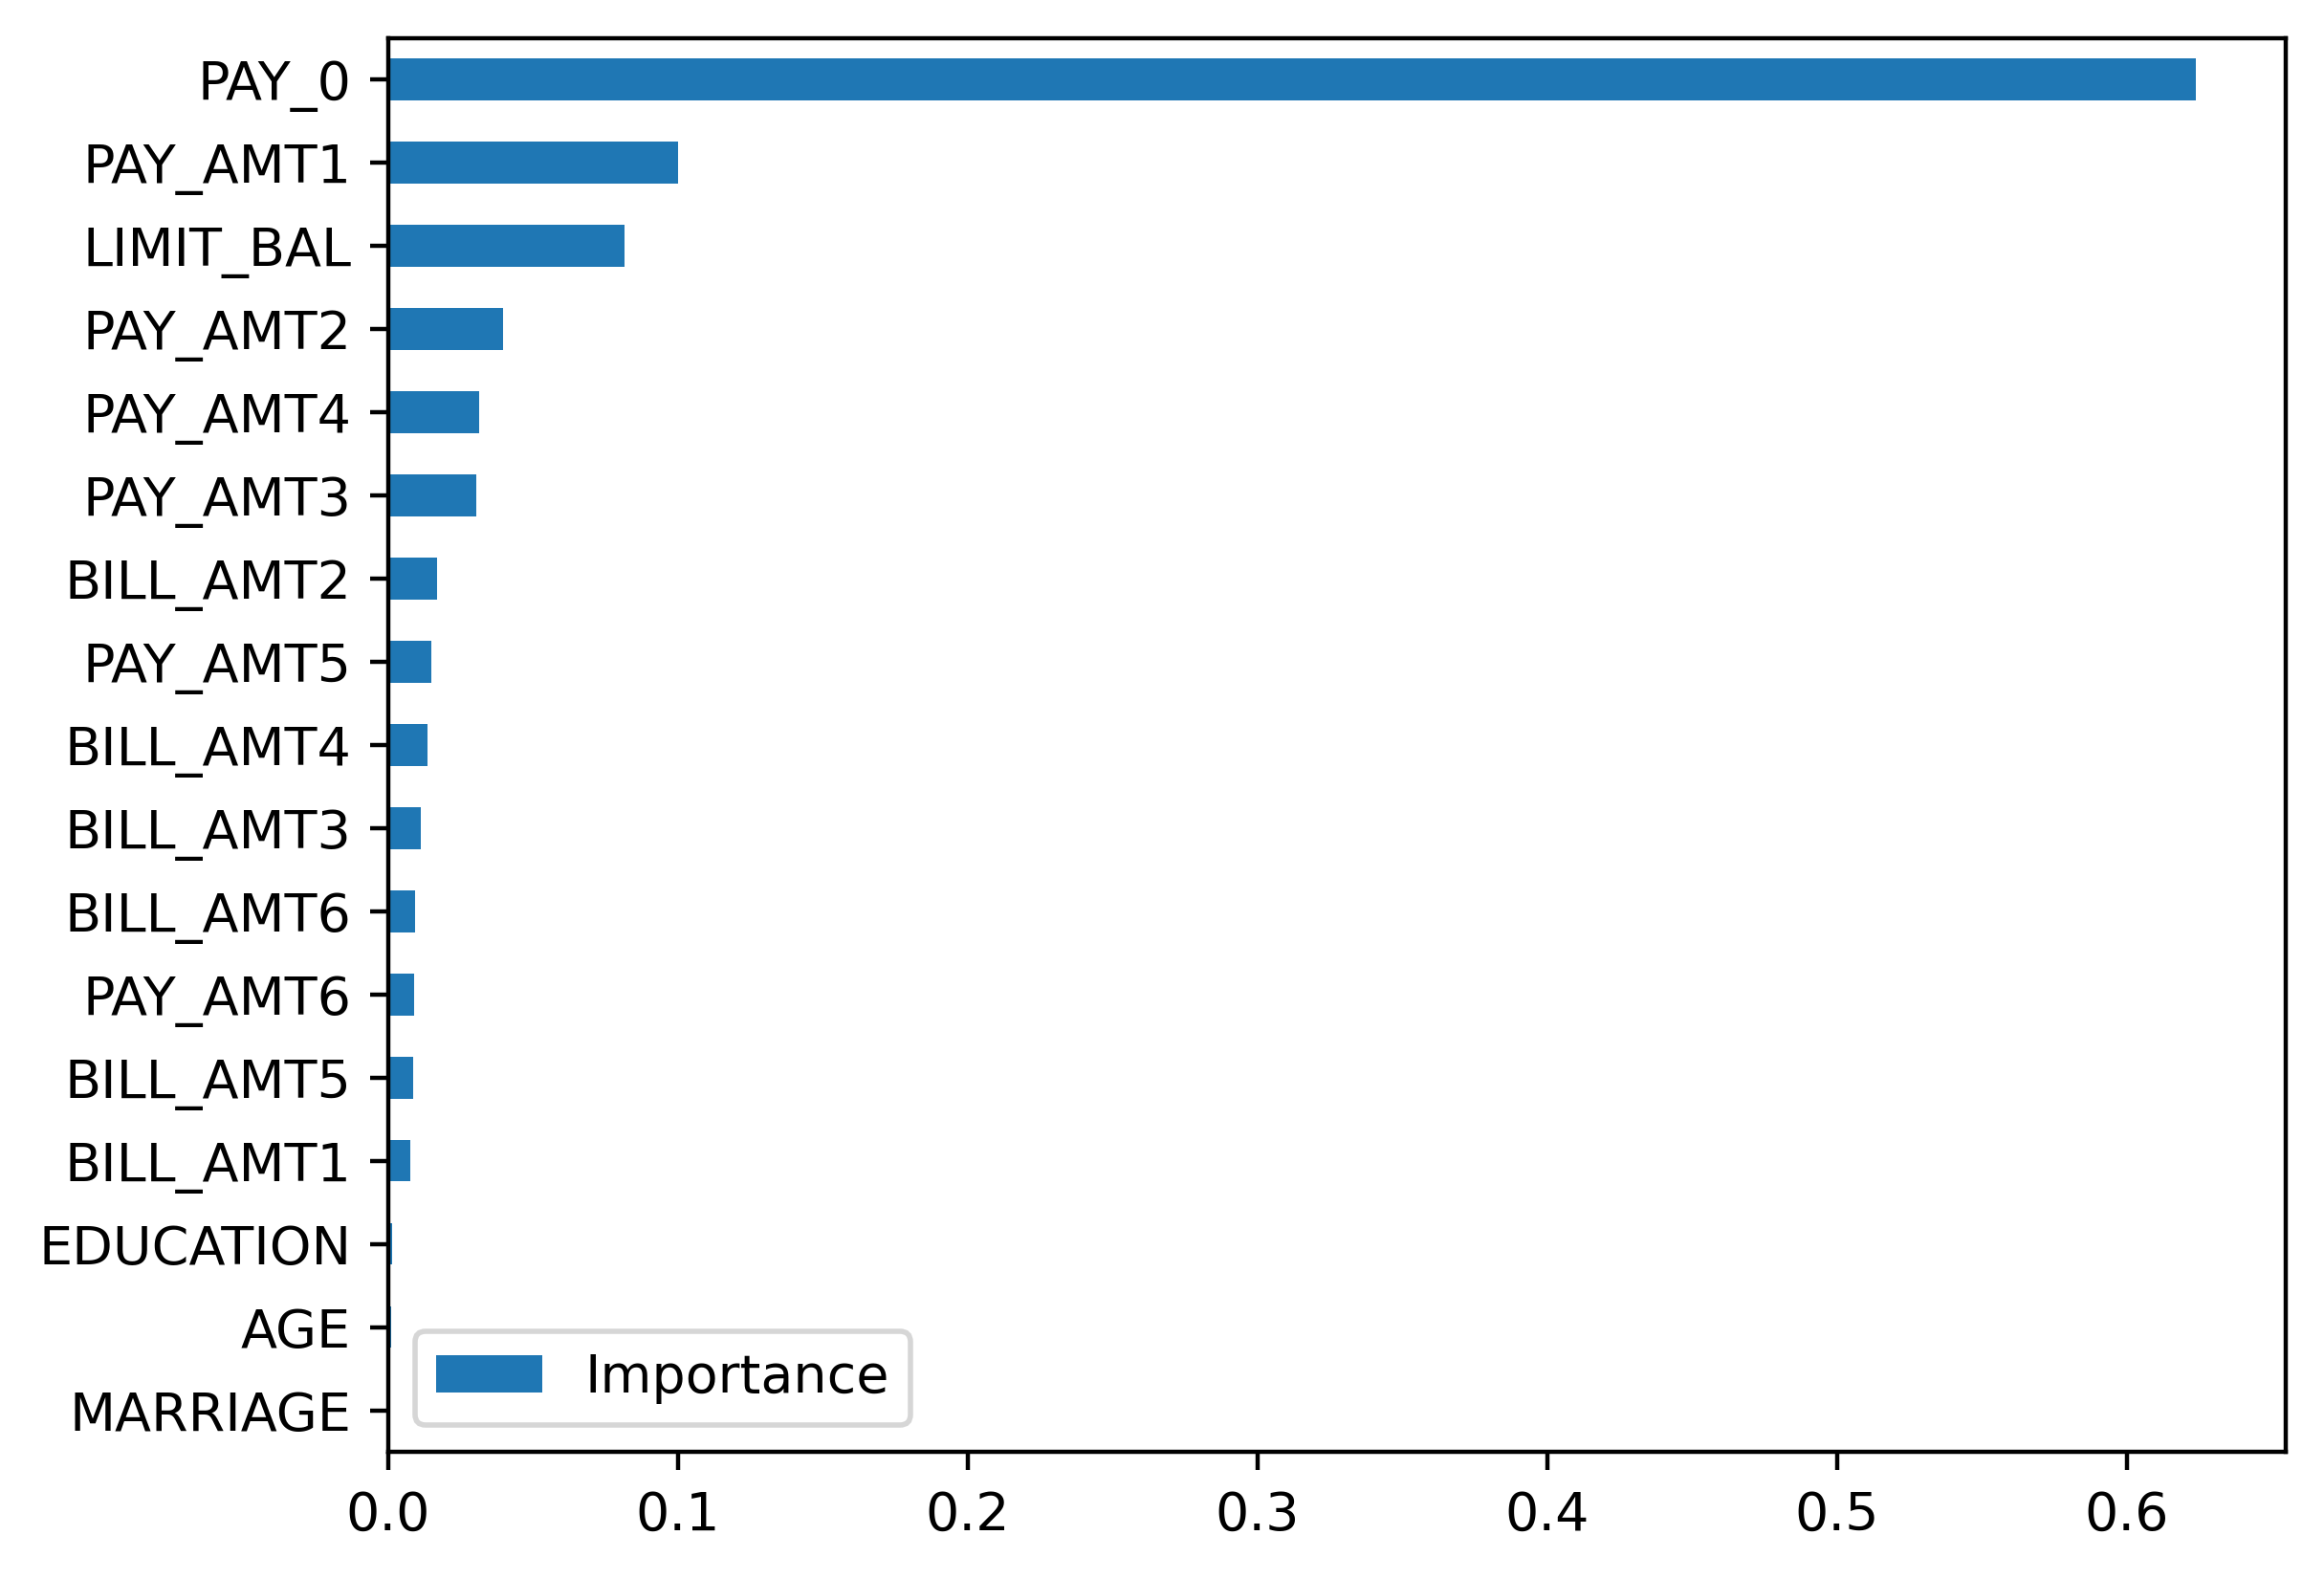

In [8]:
# {'n_estimators': 50}
cv_rf_ex.best_params_
# the feature names and importances
feat_imp_df = pd.DataFrame({
'Importance':cv_rf_ex.best_estimator_.feature_importances_},
index=features_response[:-1])
feat_imp_df.sort_values('Importance', ascending=True).plot.barh()

**Nhận xét:**

  - PAY_0 là đặc trưng quan trọng nhất, vượt trội so với các đặc trưng khác → phản ánh tình trạng thanh toán gần nhất có ảnh hưởng lớn đến khả năng vỡ nợ.

  - Các đặc trưng liên quan đến số tiền thanh toán như PAY_AMT1, PAY_AMT2, PAY_AMT4 cũng có ảnh hưởng đáng kể.

  - LIMIT_BAL (hạn mức tín dụng) đứng thứ ba → cho thấy quy mô tín dụng cũng là yếu tố quan trọng.

  - Các đặc trưng về hóa đơn (BILL_AMT1 đến BILL_AMT6) và thông tin cá nhân (EDUCATION, AGE, MARRIAGE) có mức độ ảnh hưởng thấp hơn.

**Kết luận:** Mô hình tập trung mạnh vào hành vi thanh toán gần đây hơn là thông tin cá nhân hay tổng số dư. Điều này hợp lý vì hành vi tài chính thực tế thường phản ánh rủi ro vỡ nợ rõ ràng hơn.